This is EDA on the data from the RotoWire source.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

BASE_PATH = Path(r"..\data\RotoWire\raw")

In [2]:
def ffn_from_params(params):
    fpath = os.path.join(BASE_PATH, params["year"], params["season"])
    ffn = os.path.join(fpath, f"{params["category"]}.csv")
    return ffn

# Investigate a single file (Skaters)

In [3]:
params = {
    "year": "2024",
    "season": "regular",
    "category": "skaters"
    }

ffn = ffn_from_params(params)

df = pd.read_csv(ffn, header=1)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Player Name  920 non-null    str  
 1   Team         920 non-null    str  
 2   Pos          920 non-null    str  
 3   Games        920 non-null    int64
 4   G            920 non-null    int64
 5   A            920 non-null    int64
 6   Pts          920 non-null    int64
 7   +/-          920 non-null    int64
 8   PIM          920 non-null    int64
 9   SOG          920 non-null    int64
 10  GWG          920 non-null    int64
 11  G.1          920 non-null    int64
 12  A.1          920 non-null    int64
 13  G.2          920 non-null    int64
 14  A.2          920 non-null    int64
 15  Hits         920 non-null    int64
 16  BS           920 non-null    int64
dtypes: int64(14), str(3)
memory usage: 122.3 KB
None


,Player Name,Team,Pos,Games,G,A,Pts,+/-,PIM,SOG,GWG,G.1,A.1,G.2,A.2,Hits,BS
0,Leon Draisaitl,EDM,C,71,52,54,106,32,34,240,11,16,17,0,0,23,27
1,William Nylander,TOR,C,82,45,39,84,10,26,253,8,12,18,0,0,14,27
2,Alex Ovechkin,WSH,LW,65,44,29,73,15,14,237,7,14,8,0,0,110,13
3,Tage Thompson,BUF,C,76,44,28,72,-2,35,242,6,7,9,0,0,70,31
4,David Pastrnak,BOS,RW,82,43,63,106,0,42,319,4,9,14,0,0,58,24


## Columns

- Player Name 
- Team: Present day real team
- Pos: Position
- Games: Games played that season
- G: Goals
- A: Assists
- +/-: Plus/Minus
- PIM: Penalties In Minutes
- SOG: Shots On Goal
- GWG: Game-Winning Goal
- G.1: Goals on the powerplay
- A.1: Assists on the powerplay
- G.2: Goals while shorthanded
- A.2: Assists while shorthanded
- Hits
- BS: Blocked Shots

## What are the positions?

In [7]:
df['Pos'].unique()

<StringArray>
['C', 'LW', 'RW', 'D']
Length: 4, dtype: str

## Pairplot

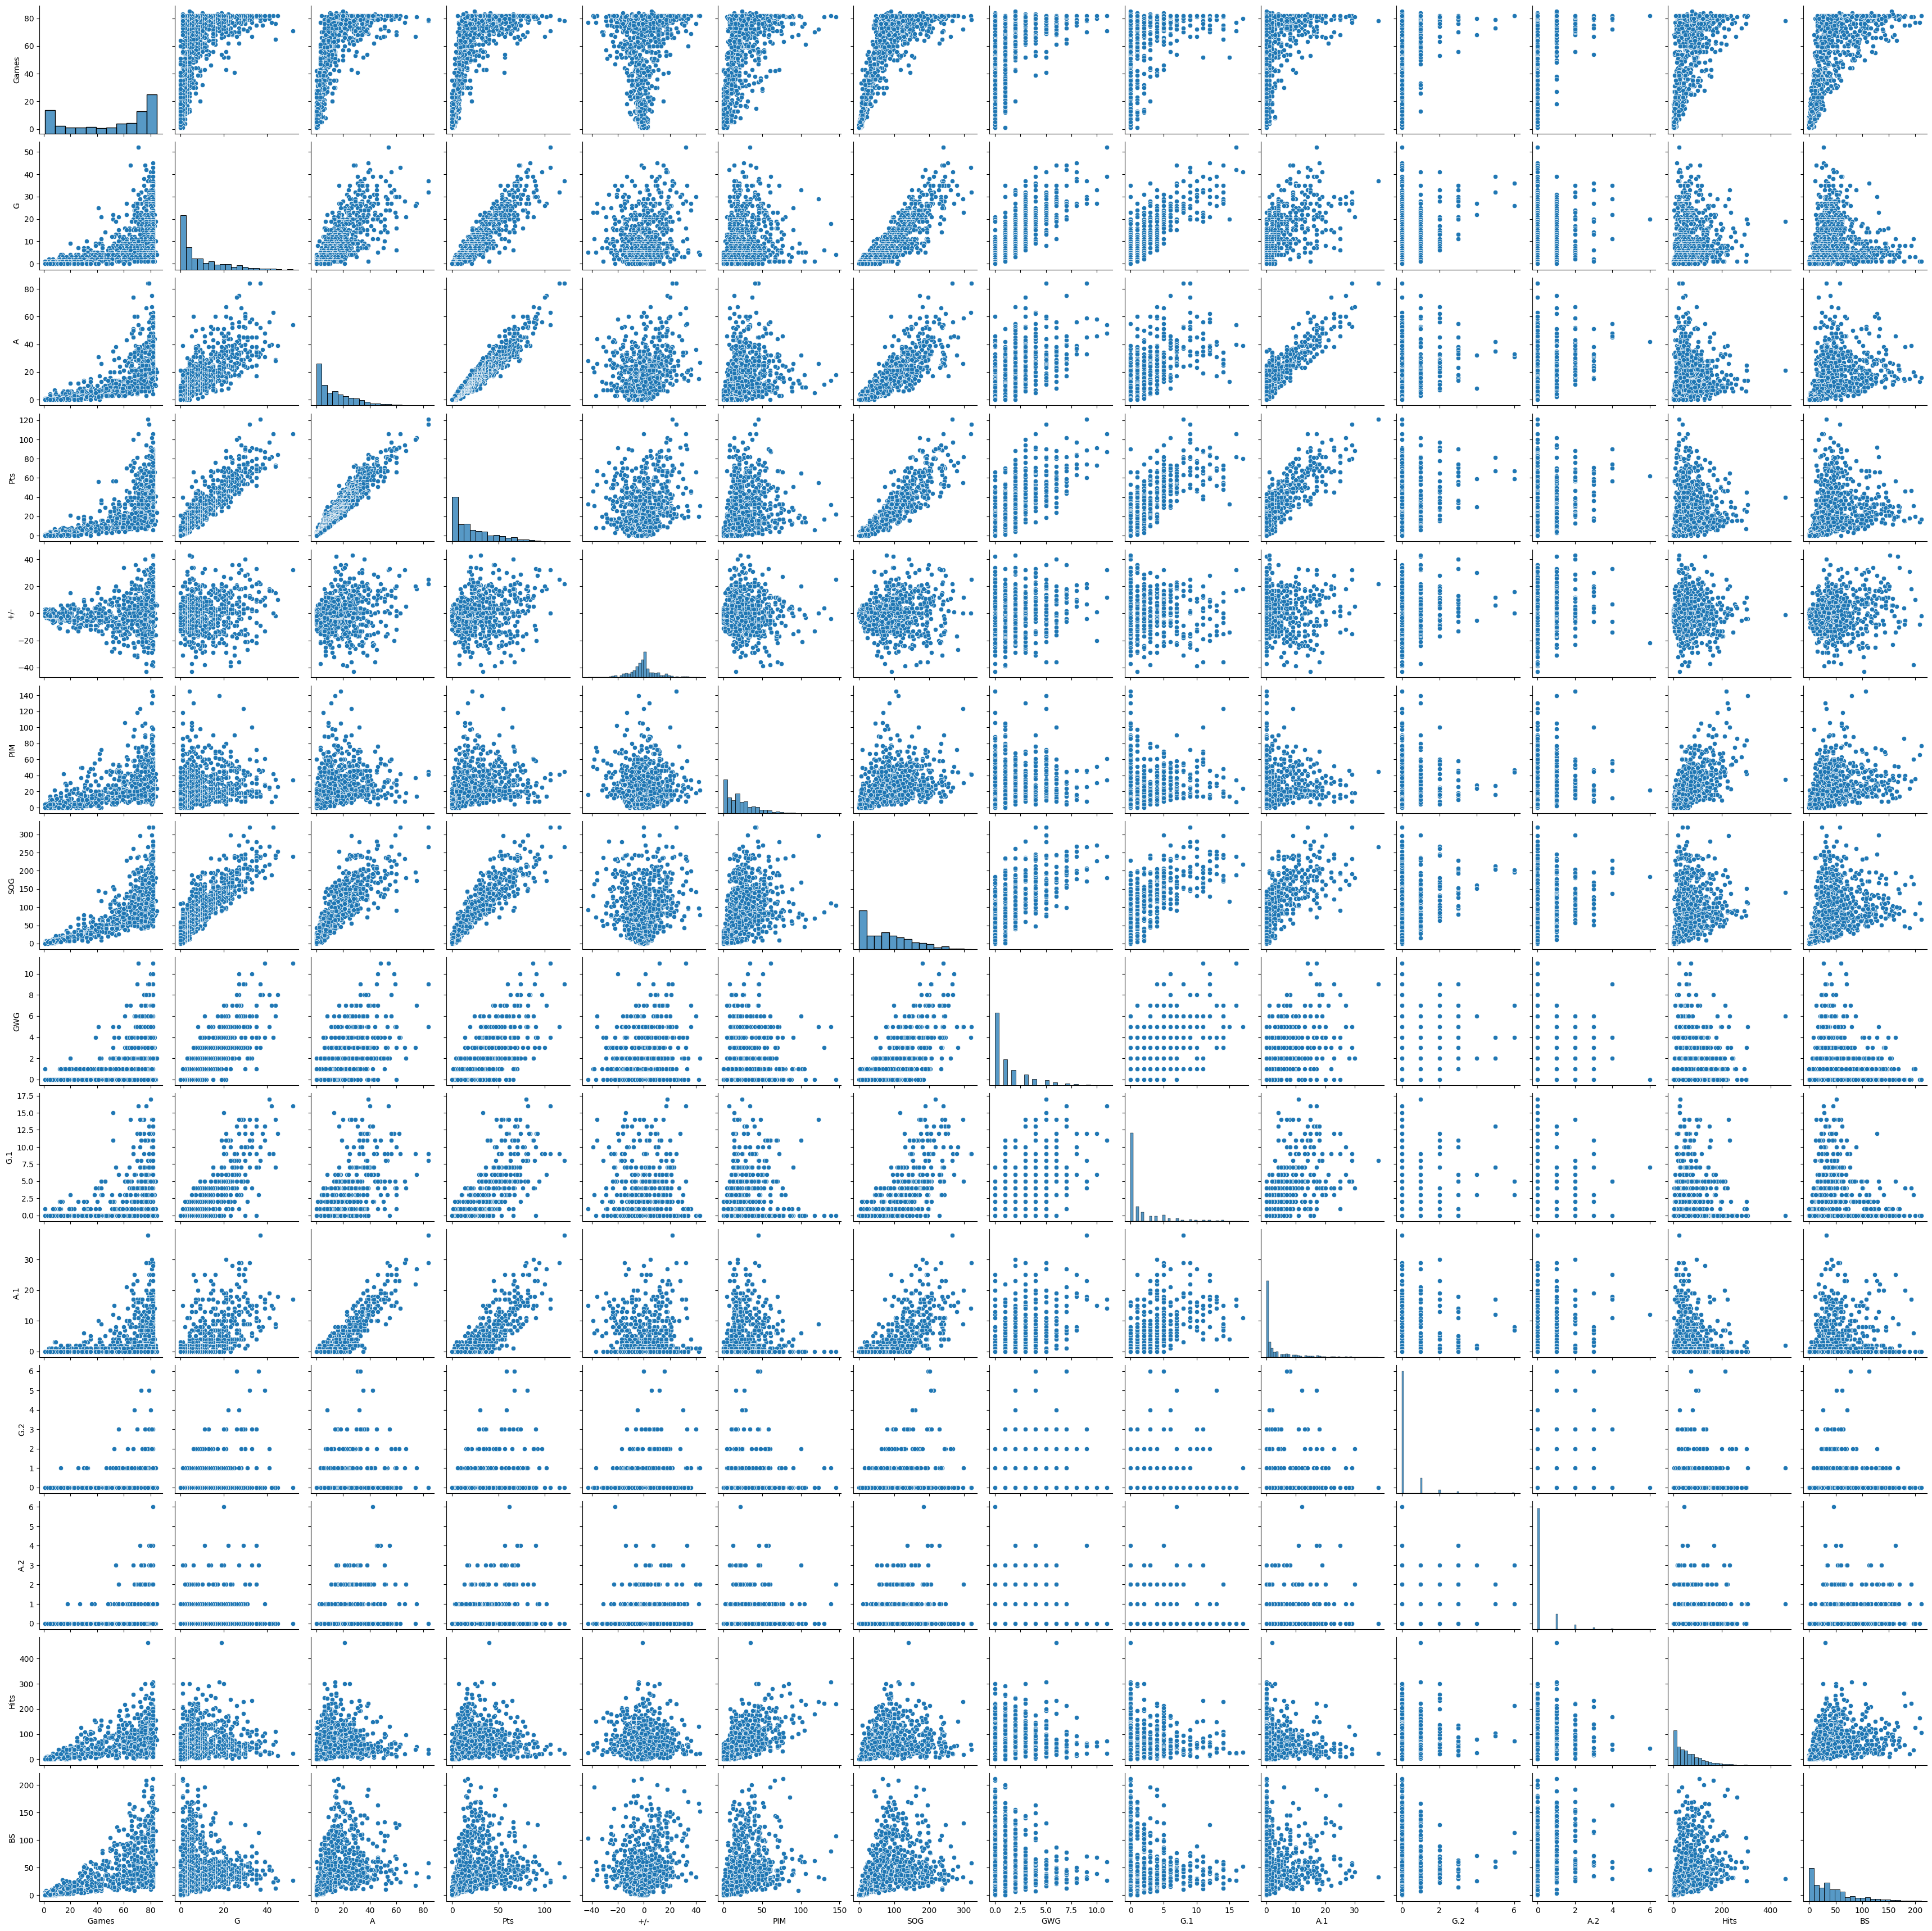

In [9]:
sns.pairplot(df)

It makes sense that all the stats are inherently linked to the number of games played. More games -> higher stats for the most part.

Metrics should be handled on a per game basis.

## Is there a minimum number of games played?

In [12]:
print(df['Games'].min())

1


No entries where there are no games played.

How many players only played one game?

In [17]:
df[df['Games'] == 1].shape[0]

32

# Investigate a single file (goalie)

In [18]:
params = {
    "year": "2024",
    "season": "regular",
    "category": "goalies"
    }

ffn = ffn_from_params(params)

df = pd.read_csv(ffn, header=1)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  103 non-null    str    
 1   Team         103 non-null    str    
 2   Games        103 non-null    int64  
 3   W            103 non-null    int64  
 4   L            103 non-null    int64  
 5   OTL          103 non-null    int64  
 6   GAA          103 non-null    float64
 7   GA           103 non-null    int64  
 8   SA           103 non-null    str    
 9   SV           103 non-null    str    
 10  SV%          103 non-null    float64
 11  SO           103 non-null    int64  
 12  MIN          103 non-null    str    
dtypes: float64(2), int64(6), str(5)
memory usage: 10.6 KB
None


,Player Name,Team,Games,W,L,OTL,GAA,GA,SA,SV,SV%,SO,MIN
0,Connor Hellebuyck,WPG,63,47,12,3,2.0,125,"1,664","1,539",0.925,8,"3,741"
1,Andrei Vasilevskiy,TBL,63,38,20,5,2.2,136,"1,716","1,580",0.921,6,"3,743"
2,Jake Oettinger,DAL,58,36,18,4,2.6,147,"1,611","1,464",0.909,2,"3,410"
3,Sergei Bobrovsky,FLA,54,33,19,2,2.5,130,"1,377","1,247",0.906,5,"3,200"
4,Adin Hill,VGK,50,32,13,5,2.5,121,"1,293","1,172",0.906,4,"2,940"


## Columns

- Player Name 
- Team: Present day real team
- Pos: Position
- Games: Games played that season
- W: Wins
- L: Losses
- OTL: Overtime Loss
- GAA: Goals Against Average
- GA: Goals Against
- SA: Shots Against
- SV: Saves
- SV%: Save Percentage
- SO: Shutouts
- MIN: Minutes played